In [1]:
import pandas as pd
import numpy as np

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
df = pd.read_csv("../data/marketing_AB_clean.csv")

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 588,101
Columns: 6


In [3]:
experiment_summary = (
    df.groupby("test group")["converted"]
    .agg(
        users="count",
        conversions="sum"
    )
)

experiment_summary["non_conversions"] = (
    experiment_summary["users"]
    - experiment_summary["conversions"]
)

experiment_summary["conversion_rate"] = (
    experiment_summary["conversions"]
    / experiment_summary["users"]
)

experiment_summary["conversion_rate_pct"] = (
    experiment_summary["conversion_rate"] * 100
)

experiment_summary

,users,conversions,non_conversions,conversion_rate,conversion_rate_pct
test group,,,,,
ad,564577,14423,550154,0.025547,2.554656
psa,23524,420,23104,0.017854,1.785411


In [4]:
ad_rate = experiment_summary.loc["ad", "conversion_rate"]
psa_rate = experiment_summary.loc["psa", "conversion_rate"]

absolute_difference = ad_rate - psa_rate

print(f"Ad conversion rate : {ad_rate:.4%}")
print(f"PSA conversion rate: {psa_rate:.4%}")
print(f"Absolute difference: {absolute_difference:.4%}")

Ad conversion rate : 2.5547%
PSA conversion rate: 1.7854%
Absolute difference: 0.7692%


In [5]:
relative_lift = (ad_rate - psa_rate) / psa_rate

print(f"Relative lift: {relative_lift:.2%}")

Relative lift: 43.09%


In [6]:
conversion_counts = np.array([
    experiment_summary.loc["ad", "conversions"],
    experiment_summary.loc["psa", "conversions"]
])

sample_sizes = np.array([
    experiment_summary.loc["ad", "users"],
    experiment_summary.loc["psa", "users"]
])

z_stat, p_value = proportions_ztest(
    count=conversion_counts,
    nobs=sample_sizes,
    alternative="two-sided"
)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.6g}")

Z-statistic: 7.3701
P-value: 1.70528e-13


In [7]:
# 95% confidence interval for the difference in conversion rates
# Difference is defined as Ad - PSA

se_diff = np.sqrt(
    (ad_rate * (1 - ad_rate) / experiment_summary.loc["ad", "users"])
    +
    (psa_rate * (1 - psa_rate) / experiment_summary.loc["psa", "users"])
)

z_critical = 1.96

ci_lower = absolute_difference - z_critical * se_diff
ci_upper = absolute_difference + z_critical * se_diff

print(f"Difference (Ad - PSA): {absolute_difference:.4%}")
print(f"95% CI Lower: {ci_lower:.4%}")
print(f"95% CI Upper: {ci_upper:.4%}")

Difference (Ad - PSA): 0.7692%
95% CI Lower: 0.5951%
95% CI Upper: 0.9434%


In [8]:
# Cohen's h effect size for difference in proportions

cohens_h = (
    2 * np.arcsin(np.sqrt(ad_rate))
    - 2 * np.arcsin(np.sqrt(psa_rate))
)

print(f"Cohen's h: {cohens_h:.4f}")

Cohen's h: 0.0530


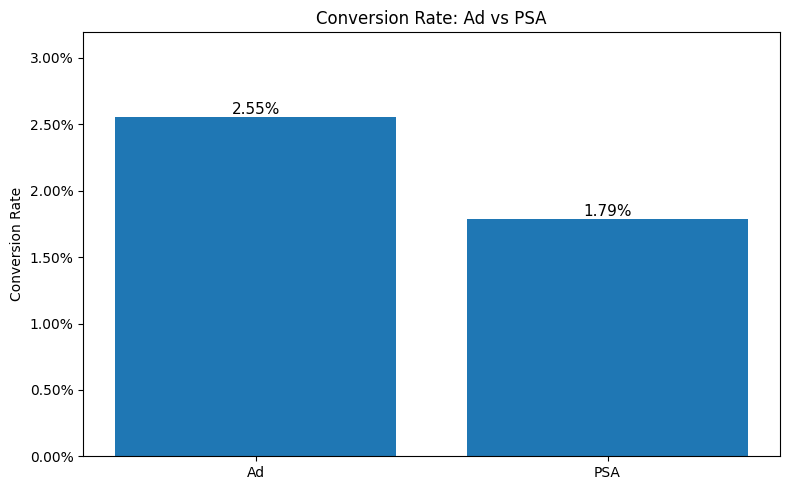

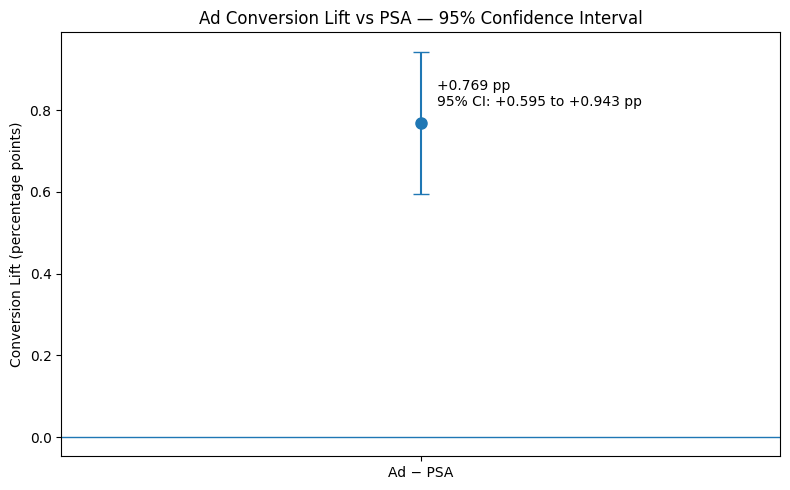

In [9]:
# Portfolio-ready experiment visuals
# Values are taken from the calculations above; no statistical results are hardcoded.
from pathlib import Path

visual_dir = Path("../visualizations")
visual_dir.mkdir(exist_ok=True)

# 1. Overall conversion rate comparison
groups = ["Ad", "PSA"]
rates = [ad_rate, psa_rate]

plt.figure(figsize=(8, 5))
bars = plt.bar(groups, rates)
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate: Ad vs PSA")
plt.ylim(0, max(rates) * 1.25)
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.2%}")
)

for bar, rate in zip(bars, rates):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{rate:.2%}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.savefig(visual_dir / "conversion_rate_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

# 2. Conversion lift with 95% confidence interval
lift_pp = absolute_difference * 100
ci_low_pp = ci_lower * 100
ci_high_pp = ci_upper * 100
error_low = lift_pp - ci_low_pp
error_high = ci_high_pp - lift_pp

plt.figure(figsize=(8, 5))
plt.errorbar(
    ["Ad − PSA"],
    [lift_pp],
    yerr=[[error_low], [error_high]],
    fmt="o",
    capsize=6,
    markersize=8
)
plt.axhline(0, linewidth=1)
plt.ylabel("Conversion Lift (percentage points)")
plt.title("Ad Conversion Lift vs PSA — 95% Confidence Interval")
plt.annotate(
    f"+{lift_pp:.3f} pp\n95% CI: +{ci_low_pp:.3f} to +{ci_high_pp:.3f} pp",
    xy=(0, lift_pp),
    xytext=(12, 10),
    textcoords="offset points",
    ha="left",
    va="bottom"
)
plt.tight_layout()
plt.savefig(visual_dir / "conversion_lift_confidence_interval.png", dpi=200, bbox_inches="tight")
plt.show()


In [10]:
# Predefined practical significance threshold

practical_threshold = 0.005  # 0.50 percentage points

print(f"Practical significance threshold: {practical_threshold:.2%}")
print(f"Observed absolute difference: {absolute_difference:.2%}")

if absolute_difference >= practical_threshold:
    print("Observed effect exceeds the practical significance threshold.")
else:
    print("Observed effect does not exceed the practical significance threshold.")

Practical significance threshold: 0.50%
Observed absolute difference: 0.77%
Observed effect exceeds the practical significance threshold.


In [11]:
# Descriptive statistics for total ads by experiment group

ads_summary = (
    df.groupby("test group")["total ads"]
    .agg(
        users="count",
        mean="mean",
        median="median",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        max="max"
    )
)

ads_summary["IQR"] = ads_summary["q3"] - ads_summary["q1"]

ads_summary

,users,mean,median,q1,q3,max,IQR
test group,,,,,,,
ad,564577,24.823365,13.0,4.0,27.0,2065,23.0
psa,23524,24.761138,12.0,4.0,26.0,907,22.0


In [12]:
# Mann–Whitney U test for total ads
# Two-sided test: H0 = the distributions are equal

ad_ads = df.loc[df["test group"] == "ad", "total ads"]
psa_ads = df.loc[df["test group"] == "psa", "total ads"]

u_stat, p_value_ads = stats.mannwhitneyu(
    ad_ads,
    psa_ads,
    alternative="two-sided"
)

print(f"Mann–Whitney U statistic: {u_stat:,.0f}")
print(f"P-value: {p_value_ads:.6g}")

Mann–Whitney U statistic: 6,808,288,222
P-value: 4.69091e-11


In [13]:
# Rank-biserial correlation effect size
# Positive value means total_ads tends to be higher in the Ad group

n_ad = len(ad_ads)
n_psa = len(psa_ads)

rank_biserial = (
    (2 * u_stat) / (n_ad * n_psa)
) - 1

print(f"Rank-biserial correlation: {rank_biserial:.4f}")

Rank-biserial correlation: 0.0253


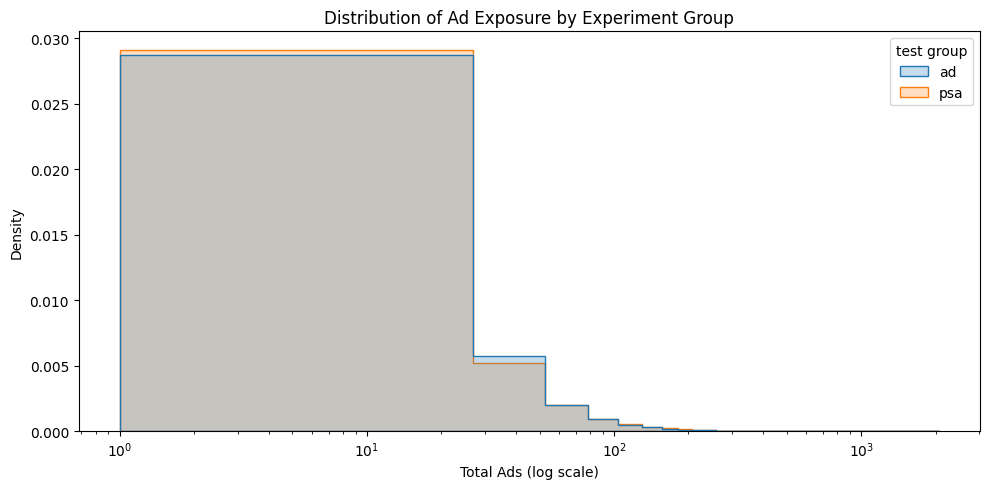

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="total ads",
    hue="test group",
    bins=80,
    element="step",
    stat="density",
    common_norm=False
)

plt.xscale("log")
plt.title("Distribution of Ad Exposure by Experiment Group")
plt.xlabel("Total Ads (log scale)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [15]:
statistical_summary = pd.DataFrame({
    "Metric": [
        "Conversion Rate — Ad",
        "Conversion Rate — PSA",
        "Absolute Conversion Difference",
        "Relative Lift",
        "95% CI — Lower",
        "95% CI — Upper",
        "Z-statistic",
        "Conversion Test P-value",
        "Cohen's h",
        "Total Ads Median — Ad",
        "Total Ads Median — PSA",
        "Mann–Whitney P-value",
        "Rank-Biserial Correlation"
    ],
    "Value": [
        f"{ad_rate:.4%}",
        f"{psa_rate:.4%}",
        f"{absolute_difference:.4%}",
        f"{relative_lift:.2%}",
        f"{ci_lower:.4%}",
        f"{ci_upper:.4%}",
        f"{z_stat:.4f}",
        f"{p_value:.6g}",
        f"{cohens_h:.4f}",
        f"{ads_summary.loc['ad', 'median']:.0f}",
        f"{ads_summary.loc['psa', 'median']:.0f}",
        f"{p_value_ads:.6g}",
        f"{rank_biserial:.4f}"
    ]
})

statistical_summary

,Metric,Value
0,Conversion Rate — Ad,2.5547%
1,Conversion Rate — PSA,1.7854%
2,Absolute Conversion Difference,0.7692%
3,Relative Lift,43.09%
4,95% CI — Lower,0.5951%
5,95% CI — Upper,0.9434%
6,Z-statistic,7.3701
7,Conversion Test P-value,1.70528e-13
8,Cohen's h,0.0530
9,Total Ads Median — Ad,13
